In [47]:
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:qwen/qwen3.6-32b") 

In [48]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [49]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce",
]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [50]:
doc_list=[item for sublist in docs for item in sublist]

text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_splits=text_splitter.split_documents(doc_list)

vector_store=FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings()
)

retriever=vector_store.as_retriever()

In [51]:
retriever.invoke("what is llms")

[Document(id='92bf71e7-d4cd-403f-8519-2e2ec3b0a5e7', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='489c6c4c-a652-44da-91e9-d362089bca46', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='be31d173-6c48-49f3-a273-0fd7f9e556e7', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [52]:
#retriever to etriever tools
from langchain_core.tools import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_documents",
    "Search and run info about langgraph"
)
retriever_tool

StructuredTool(name='retrieve_documents', description='Search and run info about langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002CAA61FAA20>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002CAA61FA340>)

### another db for langchain blogs

In [53]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/",
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessa

In [54]:
doc_list=[item for sublist in docs for item in sublist]

text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_splits=text_splitter.split_documents(doc_list)

vector_store_langchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings()
)

retrieverlangchain=vector_store_langchain.as_retriever()

In [55]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain = create_retriever_tool(
    retriever,
    "retrieve_documents_for_langchain",
    "Search and run info about langchain"
)

tools=[retriever_tool,retriever_tool_langchain]

### Langgrpah workflow

In [56]:
from typing import Annotated,Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    #the add_messages func define how an update should be processed
    #default is to replace. add_messages says "append"
    messages:Annotated[Sequence[BaseMessage],add_messages]

In [57]:
from langchain_groq import ChatGroq
#nodes
def agent(state):
    """
    
    Invoke the agent model to geenate a sresposne based on the urrent state. given the quesion,
    it will decide toretrieve tool, oir simply end.

    args:
        state (messages):the current state
    
    returns:
        dict: the updated state with the agent resposne appended to messages
    """
    print("---CALL AGENT---")
    messages=state["messages"]
    model=ChatGroq(model="groq:qwen/qwen3.6-32b")
    model=model.bind_tools(tools)
    response=model.invoke(messages)
    #we return a list, because this will get added to the exisiting list
    return{"messages":[response]}

In [58]:
from typing import Annotated, Literal
from typing import TypedDict
from langgraph.graph import END,StateGraph,START
from langgraph.prebuilt import ToolNode,tools_condition

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

In [59]:
### edges
def grade_documnets(state)-> Literal["generate","rewrite"]:
    """
    Determines wheteher the retrieved documents are relevant to the quesiton

    args:
        state(messages): the current state
    returns:
        str:a decision for whether the documents are relevant or not 
    """

    print("---CHECK RELEVANCE---")

    #data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score:str = Field(description="Relevance score 'yes' or 'no' ")

    #llm
    model=ChatGroq(model="groq:qwen/qwen3.6-32b") 

    # llm with tools
    llm_with_tool=model.with_structured_output(grade) #return with varibale str binary_score


    #prompt
    prompt=PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved docuent to a user question. \n
        here is the retrieved document: \n\n {context} \n\n
        here is the user question: {question} \n
        if the document contins keyword(s) or semantic menain related to the user questionbs, gradew it as rleevant. \n
        gve a binar score 'yes' or 'no' score to indicate whether the dopcument is rleevant to the question.""",
        input_variables=["context","question"],
    )

    #chain
    chain=prompt|llm_with_tool

    messages=state["messages"]
    last_message=messages[-1] #the last message


    question=messages[0].content
    docs=last_message.content

    scored_result=chain.invoke({"question":question,"context":docs})

    score=scored_result.binary_score

    if score=="yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate" #will go the generate func
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite" #will go the rewrite func

In [60]:
from langchain_classic import hub
def generate(state):
    """
    Generate answer

    Args:
        state(messages):The current state

    Returns:
        dict:The updated message
    """
    print("---GENERATE---")
    messages=state["messages"]
    question=messages[0].content
    last_message=messages[-1]

    docs=last_message.content

    #Prompt
    prompt=hub.pull("rlm/rag-prompt")

    #LLM
    llm=ChatGroq(model="groq:qwen/qwen3.6-32b")

    #Post-preprocessing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    #chain
    rag_chain=prompt|llm|StrOutputParser()

    #RUN
    response=rag_chain.invoke({"context":docs,"question":question})
    return {"messages":[response]}

In [61]:
def rewrite(state):
    """
    Transform the query to prodcue a better question.

    Args:
        state(messages):The current state

    Returns:
        dict:The updated state with re-phrased qquestion
    """
    print("---TRANSFORM QUERY---")
    messages=state["messages"]
    question=messages[0].content

    msg=[HumanMessage(
        content=f"""\n
    look at the input and try to reason about the underlying semantic inent \ meaning. \n
    here is the initial question:
    \n -------- \n
    {question}
    \n -------- \n
    Formulate an improved question:""",
    )]

    #Grader
    model=ChatGroq(model="groq:qwen/qwen3.6-32b")
    response=model.invoke(msg)
    return {"messages":[response]}

<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Moham\AppData\Local\Temp\ipykernel_16444\2237287558.py:22: SyntaxWarning: invalid escape sequence '\ '
  Formulate an improved question:""",


<unknown>:22: SyntaxWarning: invalid escape sequence '\ '


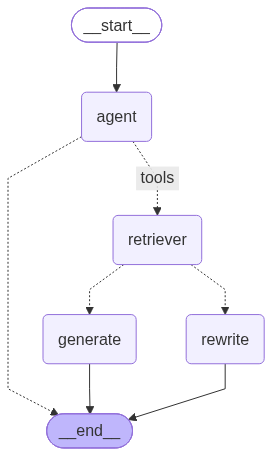

In [62]:
from IPython.display import Image,display
#defien a stategrpah
workflow=StateGraph(AgentState)

workflow.add_node("agent",agent)
retriever=ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retriever",retriever)
workflow.add_node("rewrite",rewrite)
workflow.add_node("generate",generate)
workflow.add_edge(START,"agent")
workflow.add_conditional_edges(
    "agent",
    tools_condition,{
        "tools":"retriever",
        END:END
    },
)

workflow.add_conditional_edges(
    "retriever",
    grade_documnets,
)
workflow.add_edge("generate",END)
workflow.add_edge("rewrite",END)

graph=workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [63]:
graph.invoke({"messages":"what is langgraph"})

---CALL AGENT---


NotFoundError: Error code: 404 - {'error': {'message': 'The model `groq:qwen/qwen3.6-32b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [ ]:
graph.invoke({"messages":"what is machine learning"})

---CALL AGENT---


NotFoundError: Error code: 404 - {'error': {'message': 'The model `qwen/qwen3.6-32b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}